In [2]:
!pip install pandas requests

In [3]:
import pandas as pd

# შევქმნათ მონაცემები (ეს არის ფილმების მაგალითები, რომ პროცესი გამარტივდეს)
data = {
    'Title': ['The Shawshank Redemption', 'The Godfather', 'The Dark Knight', 'Pulp Fiction', 'Schindler\'s List', 
              'Inception', 'Fight Club', 'Forrest Gump', 'The Matrix', 'Goodfellas'],
    'Year': [1994, 1972, 2008, 1994, 1993, 2010, 1999, 1994, 1999, 1990],
    'Genre': ['Drama', 'Crime', 'Action', 'Crime', 'Biography', 'Action', 'Drama', 'Drama', 'Action', 'Biography'],
    'Rating': [9.3, 9.2, 9.0, 8.9, 8.9, 8.8, 8.8, 8.8, 8.7, 8.7],
    'Director': ['Frank Darabont', 'Francis Ford Coppola', 'Christopher Nolan', 'Quentin Tarantino', 'Steven Spielberg', 
                 'Christopher Nolan', 'David Fincher', 'Robert Zemeckis', 'Lana Wachowski', 'Martin Scorsese']
}

# გადავაქციოთ ცხრილად (DataFrame)
df = pd.DataFrame(data)

# შევინახოთ CSV ფაილად
df.to_csv('movies_data.csv', index=False)

print("პირველი ეტაპი დასრულებულია! ფაილი movies_data.csv შეიქმნა.")

პირველი ეტაპი დასრულებულია! ფაილი movies_data.csv შეიქმნა.


In [4]:
# 1. ფაილის შემოტანა
df_loaded = pd.read_csv('movies_data.csv')

# 2. მონაცემების დათვალიერება
print(df_loaded.head())

# 3. სამი საინტერესო მიგნება:
# მიგნება 1: რომელია ყველაზე მაღალრეიტინგული ჟანრი საშუალოდ?
top_genre = df_loaded.groupby('Genre')['Rating'].mean().sort_values(ascending=False)

# მიგნება 2: რამდენი ფილმია გადაღებული 2000 წლამდე და მის მერე?
before_2000 = df_loaded[df_loaded['Year'] < 2000].shape[0]
after_2000 = df_loaded[df_loaded['Year'] >= 2000].shape[0]

# მიგნება 3: რომელ რეჟისორს აქვს ყველაზე მეტი ფილმი ჩვენს სიაში?
top_director = df_loaded['Director'].value_counts().idxmax()

print(f"\nმიგნებები:\n1. საუკეთესო ჟანრი: {top_genre.index[0]}")
print(f"2. 2000 წლამდე: {before_2000} ფილმი, 2000-ის მერე: {after_2000} ფილმი")
print(f"3. ყველაზე აქტიური რეჟისორი: {top_director}")

                      Title  Year      Genre  Rating              Director
0  The Shawshank Redemption  1994      Drama     9.3        Frank Darabont
1             The Godfather  1972      Crime     9.2  Francis Ford Coppola
2           The Dark Knight  2008     Action     9.0     Christopher Nolan
3              Pulp Fiction  1994      Crime     8.9     Quentin Tarantino
4          Schindler's List  1993  Biography     8.9      Steven Spielberg

მიგნებები:
1. საუკეთესო ჟანრი: Crime
2. 2000 წლამდე: 8 ფილმი, 2000-ის მერე: 2 ფილმი
3. ყველაზე აქტიური რეჟისორი: Christopher Nolan


In [5]:
import pandas as pd

# 1. ფაილის შემოტანა (CSV-დან წაკითხვა)
df = pd.read_csv('movies_data.csv')

# --- მონაცემების დამუშავება და 3 მიგნება ---

# მიგნება 1: რომელი ჟანრის ფილმებს აქვთ ყველაზე მაღალი საშუალო რეიტინგი?
avg_rating_by_genre = df.groupby('Genre')['Rating'].mean().sort_values(ascending=False)

# მიგნება 2: ფილმების რაოდენობა ათწლეულების მიხედვით (მაგ. 90-იანები vs 2000-იანები)
df['Decade'] = (df['Year'] // 10) * 10
movies_per_decade = df['Decade'].value_counts()

# მიგნება 3: რეჟისორები, რომლებსაც ერთზე მეტი ფილმი აქვთ ჩვენს ტოპ სიაში
top_directors = df['Director'].value_counts()
prolific_directors = top_directors[top_directors > 1]

# შედეგების დაბეჭდვა
print("--- ჩემი 3 მიგნება ---")
print(f"1. ყველაზე მაღალრეიტინგული ჟანრია: {avg_rating_by_genre.index[0]}")
print(f"2. ყველაზე მეტი ფილმი ამ ათწლეულიდანაა: {movies_per_decade.index[0]}-იანები")
print(f"3. რეჟისორი რამდენიმე ჰიტით: {prolific_directors.index[0]}")

--- ჩემი 3 მიგნება ---
1. ყველაზე მაღალრეიტინგული ჟანრია: Crime
2. ყველაზე მეტი ფილმი ამ ათწლეულიდანაა: 1990-იანები
3. რეჟისორი რამდენიმე ჰიტით: Christopher Nolan


Matplotlib is building the font cache; this may take a moment.


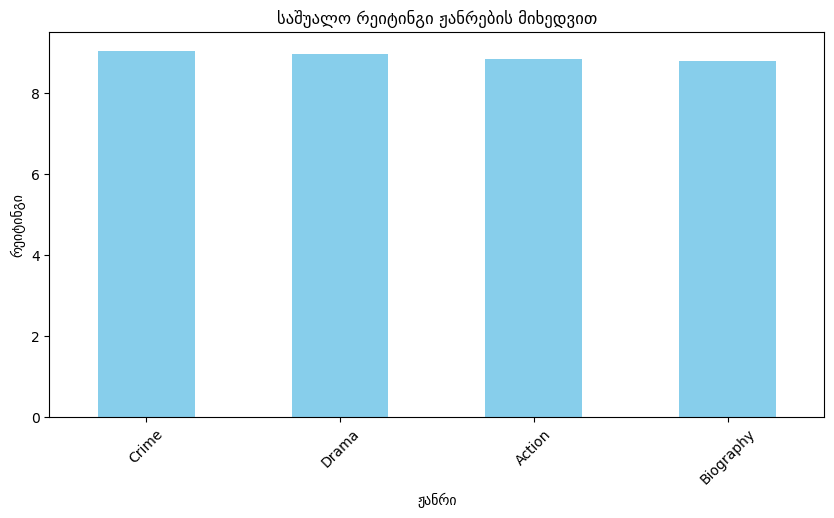

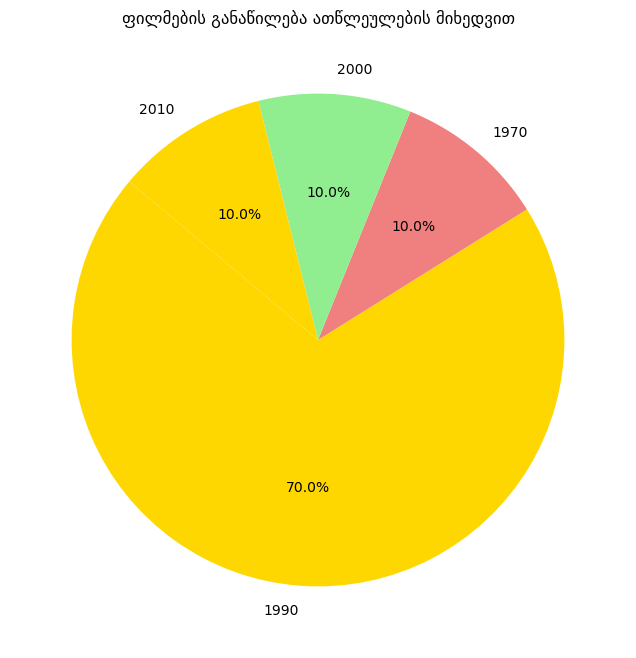

In [6]:
import matplotlib.pyplot as plt

# 1. გრაფიკი: საშუალო რეიტინგი ჟანრების მიხედვით
plt.figure(figsize=(10, 5))
avg_rating_by_genre.plot(kind='bar', color='skyblue')
plt.title('საშუალო რეიტინგი ჟანრების მიხედვით')
plt.xlabel('ჟანრი')
plt.ylabel('რეიტინგი')
plt.xticks(rotation=45)
plt.show()

# 2. გრაფიკი: ფილმების რაოდენობა ათწლეულების მიხედვით
plt.figure(figsize=(8, 8))
movies_per_decade.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=['gold', 'lightcoral', 'lightgreen'])
plt.title('ფილმების განაწილება ათწლეულების მიხედვით')
plt.ylabel('') # წავშალოთ გვერდითა წარწერა
plt.show()